## 1. Install Dependencies

In [1]:
!pip install transformers datasets torch scikit-learn pandas openpyxl==3.1.0 seaborn matplotlib --quiet

## 2. Imports

In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup,
)


SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


## 3. Load & Explore the Data

In [2]:
DATA_PATH = "/Users/iliakozhevnikov/Downloads/Mental_issues_dataset.xlsx"

df = pd.read_excel(DATA_PATH)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (120, 3)


,health_concerns,class_txt,class_num
0,I can’t stop my brain from racing through ever...,Generalized Anxiety Disorder,1
1,"Lately, I feel like I’m constantly on edge, li...",Generalized Anxiety Disorder,1
2,I’m constantly checking the news and researchi...,Generalized Anxiety Disorder,1
3,"Making even simple choices, like what to have ...",Generalized Anxiety Disorder,1
4,I’m tired all the time but I can’t sleep. My m...,Generalized Anxiety Disorder,1


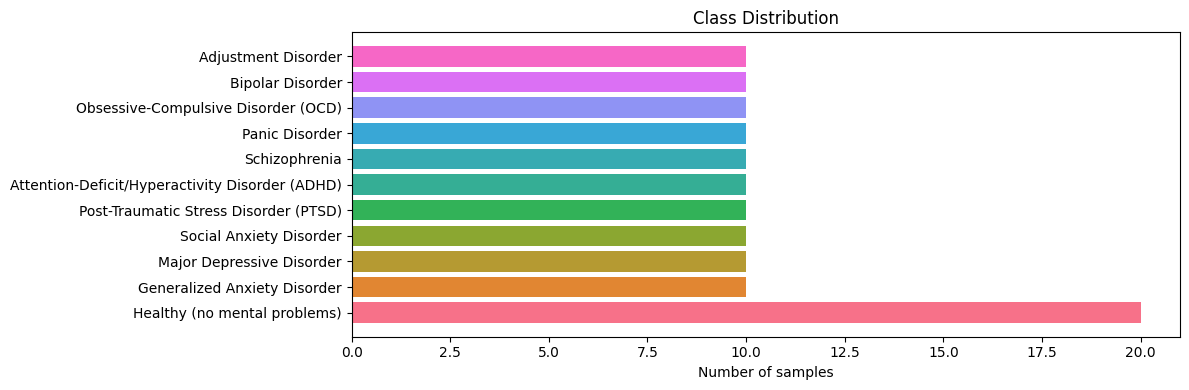


Class counts:
  [ 0] Healthy (no mental problems)                     — 20 samples
  [ 1] Generalized Anxiety Disorder                     — 10 samples
  [ 2] Major Depressive Disorder                        — 10 samples
  [ 3] Social Anxiety Disorder                          — 10 samples
  [ 4] Post-Traumatic Stress Disorder (PTSD)            — 10 samples
  [ 5] Attention-Deficit/Hyperactivity Disorder (ADHD)  — 10 samples
  [ 6] Schizophrenia                                    — 10 samples
  [ 7] Panic Disorder                                   — 10 samples
  [ 8] Obsessive-Compulsive Disorder (OCD)              — 10 samples
  [ 9] Bipolar Disorder                                 — 10 samples
  [10] Adjustment Disorder                              — 10 samples


In [3]:
label_map = (
    df[['class_num', 'class_txt']]
    .drop_duplicates()
    .sort_values('class_num')
    .set_index('class_num')['class_txt']
    .to_dict()
)

counts = df['class_num'].value_counts().sort_index()

plt.figure(figsize=(12, 4))
bars = plt.barh(
    [label_map[i] for i in counts.index],
    counts.values,
    color=sns.color_palette("husl", len(counts))
)
plt.xlabel("Number of samples")
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

print("\nClass counts:")
for cls, cnt in counts.items():
    print(f"  [{cls:>2}] {label_map[cls]:<48} — {cnt} samples")

count    120.000000
mean      41.708333
std        5.526705
min       31.000000
25%       39.000000
50%       41.000000
75%       44.000000
max       60.000000
Name: text_len, dtype: float64


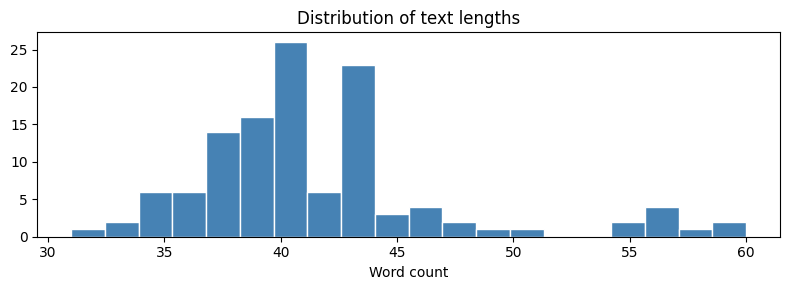

In [4]:
# Text length distribution
df['text_len'] = df['health_concerns'].str.split().str.len()
print(df['text_len'].describe())

plt.figure(figsize=(8, 3))
plt.hist(df['text_len'], bins=20, color='steelblue', edgecolor='white')
plt.xlabel("Word count")
plt.title("Distribution of text lengths")
plt.tight_layout()
plt.show()

## 4. Train / Validation Split

In [5]:
NUM_LABELS = df['class_num'].nunique()
print(f"Number of classes: {NUM_LABELS}")

X = df['health_concerns'].tolist()
y = df['class_num'].tolist()

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y          # preserve class balance
)

print(f"Train samples : {len(X_train)}")
print(f"Val   samples : {len(X_val)}")

Number of classes: 11
Train samples : 96
Val   samples : 24


## 5. Tokenizer & PyTorch Dataset

In [6]:
MODEL_NAME = "bert-base-uncased"
MAX_LEN    = 256        # Most texts fit well under 256 tokens

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)


class MentalHealthDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            texts,
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'token_type_ids': self.encodings['token_type_ids'][idx],
            'labels':         self.labels[idx]
        }


train_dataset = MentalHealthDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = MentalHealthDataset(X_val,   y_val,   tokenizer, MAX_LEN)

BATCH_SIZE = 8   # Lower if GPU memory is tight; increase for faster training

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)

print("Tokenisation complete.")
print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")

Tokenisation complete.
Train batches: 12  |  Val batches: 3


## 6. Model Setup

In [7]:
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    hidden_dropout_prob=0.3,         # regularisation
    attention_probs_dropout_prob=0.3
)
model = model.to(DEVICE)

# Hyperparameters
EPOCHS       = 10
LR           = 2e-5
WARMUP_STEPS = 0

total_steps  = len(train_loader) * EPOCHS

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps
)

print(f"Model loaded — {sum(p.numel() for p in model.parameters()):,} parameters")
print(f"Training for {EPOCHS} epochs  ({total_steps} optimiser steps)")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded — 109,490,699 parameters
Training for 10 epochs  (120 optimiser steps)


## 7. Training Loop

In [8]:
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            token_type_ids = batch['token_type_ids'].to(DEVICE)
            labels         = batch['labels'].to(DEVICE)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
                labels=labels
            )
            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc  = accuracy_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds, average='weighted')
    return avg_loss, acc, f1, all_labels, all_preds


history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
best_val_f1   = 0.0
best_model_path = "best_bert_mental_health.pt"

for epoch in range(1, EPOCHS + 1):
    # ── Training ──
    model.train()
    running_loss = 0.0

    for step, batch in enumerate(train_loader, 1):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        token_type_ids = batch['token_type_ids'].to(DEVICE)
        labels         = batch['labels'].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            labels=labels
        )
        outputs.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        running_loss += outputs.loss.item()

    train_loss = running_loss / len(train_loader)

    # ── Validation ──
    val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(
        f"Epoch {epoch:>2}/{EPOCHS}  "
        f"train_loss={train_loss:.4f}  "
        f"val_loss={val_loss:.4f}  "
        f"val_acc={val_acc:.4f}  "
        f"val_f1={val_f1:.4f}"
    )

    # Save best checkpoint
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), best_model_path)
        print(f"    ✓ Best model saved (val_f1={best_val_f1:.4f})")

print(f"\nTraining complete. Best val F1: {best_val_f1:.4f}")

Epoch  1/10  train_loss=2.4476  val_loss=2.3872  val_acc=0.1667  val_f1=0.0556
    ✓ Best model saved (val_f1=0.0556)
Epoch  2/10  train_loss=2.4413  val_loss=2.3541  val_acc=0.2500  val_f1=0.1257
    ✓ Best model saved (val_f1=0.1257)
Epoch  3/10  train_loss=2.3351  val_loss=2.3240  val_acc=0.1667  val_f1=0.0476
Epoch  4/10  train_loss=2.3063  val_loss=2.3103  val_acc=0.2500  val_f1=0.1346
    ✓ Best model saved (val_f1=0.1346)
Epoch  5/10  train_loss=2.2694  val_loss=2.2900  val_acc=0.2500  val_f1=0.1200
Epoch  6/10  train_loss=2.2140  val_loss=2.2060  val_acc=0.2500  val_f1=0.1367
    ✓ Best model saved (val_f1=0.1367)
Epoch  7/10  train_loss=2.1896  val_loss=2.1666  val_acc=0.2917  val_f1=0.1663
    ✓ Best model saved (val_f1=0.1663)
Epoch  8/10  train_loss=2.1785  val_loss=2.1805  val_acc=0.2500  val_f1=0.1222
Epoch  9/10  train_loss=2.0899  val_loss=2.1889  val_acc=0.2500  val_f1=0.1222
Epoch 10/10  train_loss=2.0905  val_loss=2.1993  val_acc=0.2500  val_f1=0.1200

Training compl

## 8. Training Curves

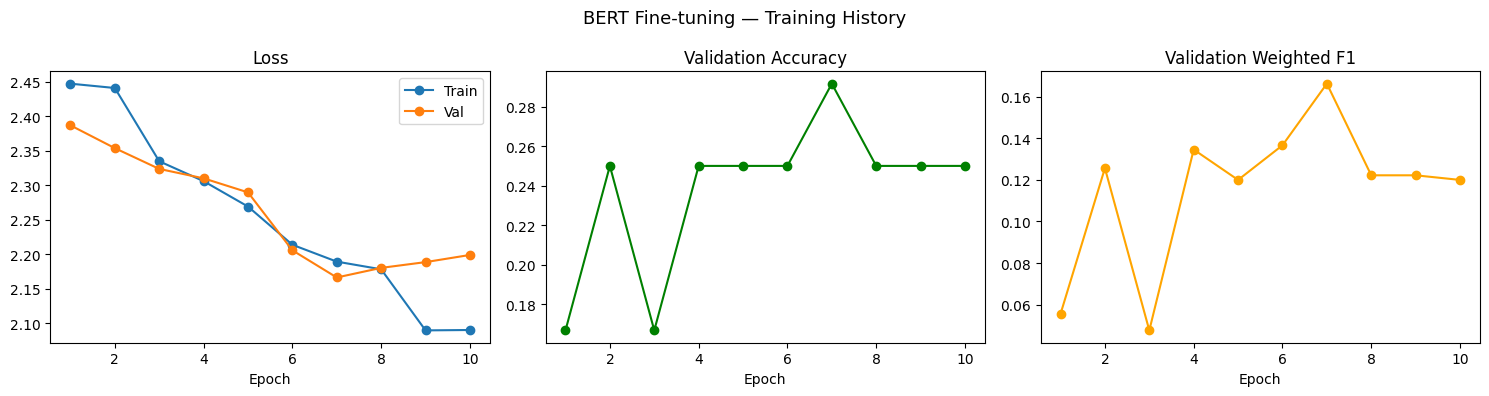

In [9]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs_range, history['train_loss'], label='Train', marker='o')
axes[0].plot(epochs_range, history['val_loss'],   label='Val',   marker='o')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(epochs_range, history['val_acc'], color='green', marker='o')
axes[1].set_title('Validation Accuracy'); axes[1].set_xlabel('Epoch')

axes[2].plot(epochs_range, history['val_f1'], color='orange', marker='o')
axes[2].set_title('Validation Weighted F1'); axes[2].set_xlabel('Epoch')

plt.suptitle('BERT Fine-tuning — Training History', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Evaluate Best Model

In [10]:
# Reload best checkpoint
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

val_loss, val_acc, val_f1, true_labels, pred_labels = evaluate(model, val_loader)

print(f"Validation Loss     : {val_loss:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Validation F1 (w)   : {val_f1:.4f}")
print()
print(classification_report(
    true_labels, pred_labels,
    target_names=[label_map[i] for i in range(NUM_LABELS)]
))

Validation Loss     : 2.1666
Validation Accuracy : 0.2917
Validation F1 (w)   : 0.1663

                                                 precision    recall  f1-score   support

                   Healthy (no mental problems)       0.21      1.00      0.35         4
                   Generalized Anxiety Disorder       0.67      1.00      0.80         2
                      Major Depressive Disorder       0.00      0.00      0.00         2
                        Social Anxiety Disorder       0.00      0.00      0.00         2
          Post-Traumatic Stress Disorder (PTSD)       0.00      0.00      0.00         2
Attention-Deficit/Hyperactivity Disorder (ADHD)       0.50      0.50      0.50         2
                                  Schizophrenia       0.00      0.00      0.00         2
                                 Panic Disorder       0.00      0.00      0.00         2
            Obsessive-Compulsive Disorder (OCD)       0.00      0.00      0.00         2
                     

/Users/iliakozhevnikov/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/iliakozhevnikov/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/iliakozhevnikov/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

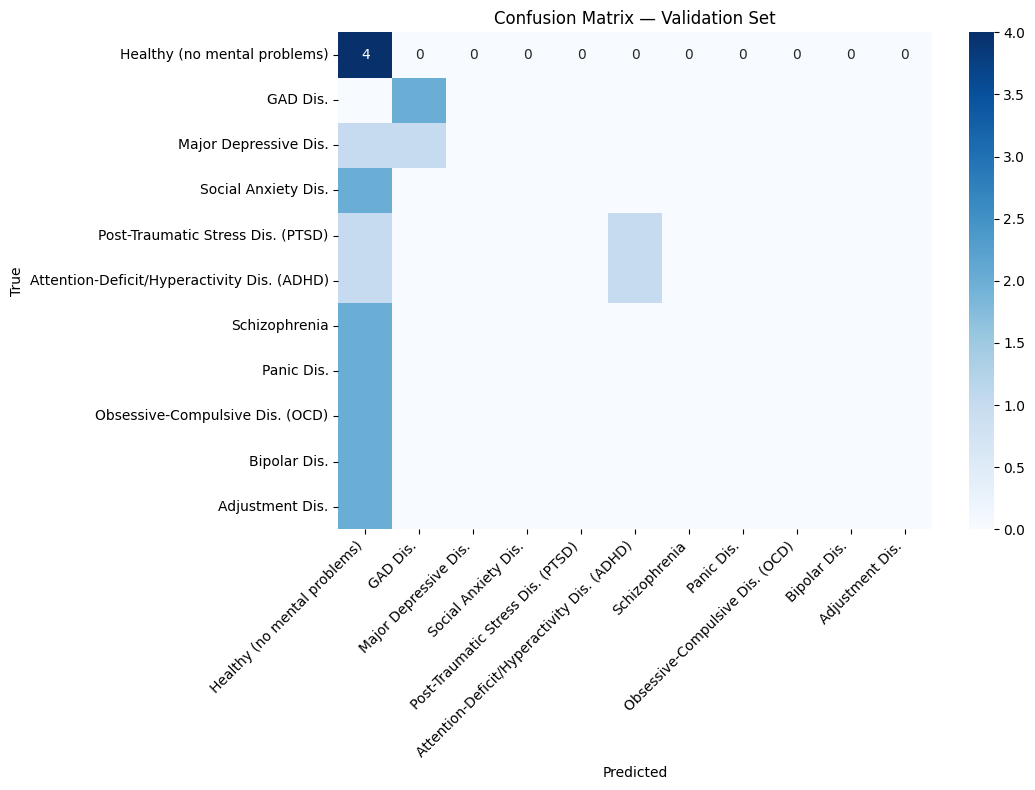

In [11]:
# Confusion matrix
cm = confusion_matrix(true_labels, pred_labels)
short_labels = [
    label_map[i].replace('Disorder', 'Dis.').replace('Generalized Anxiety', 'GAD')
    for i in range(NUM_LABELS)
]

plt.figure(figsize=(11, 8))
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=short_labels,
    yticklabels=short_labels,
    cmap='Blues'
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix — Validation Set')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 10. Inference on New Patient Text

In [12]:
def predict(text: str, model=model, tokenizer=tokenizer,
            max_len=MAX_LEN, device=DEVICE, label_map=label_map):
    """Return predicted class_num, diagnosis label, and class probabilities."""
    model.eval()
    encoding = tokenizer(
        text,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    with torch.no_grad():
        outputs = model(
            input_ids      = encoding['input_ids'].to(device),
            attention_mask = encoding['attention_mask'].to(device),
            token_type_ids = encoding['token_type_ids'].to(device)
        )
    probs      = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]
    class_num  = int(probs.argmax())
    diagnosis  = label_map[class_num]
    confidence = probs[class_num]
    return class_num, diagnosis, confidence, probs


# ── Demo ──
sample_texts = [
    # Likely anxiety
    "I can't stop worrying about everything. Even small things feel catastrophic and I'm always waiting for something bad to happen.",
    # Likely depression
    "I've lost all interest in things I used to enjoy. Getting out of bed feels impossible and I feel completely empty.",
    # Likely PTSD
    "I keep having nightmares about the accident. A car backfiring sends me into a panic and I avoid driving completely.",
]

for text in sample_texts:
    cls, diag, conf, probs = predict(text)
    print(f"Text     : {text[:90]}...")
    print(f"Diagnosis: [{cls}] {diag}  (confidence: {conf:.1%})")
    print()

Text     : I can't stop worrying about everything. Even small things feel catastrophic and I'm always...
Diagnosis: [1] Generalized Anxiety Disorder  (confidence: 17.5%)

Text     : I've lost all interest in things I used to enjoy. Getting out of bed feels impossible and ...
Diagnosis: [1] Generalized Anxiety Disorder  (confidence: 15.8%)

Text     : I keep having nightmares about the accident. A car backfiring sends me into a panic and I ...
Diagnosis: [1] Generalized Anxiety Disorder  (confidence: 16.3%)



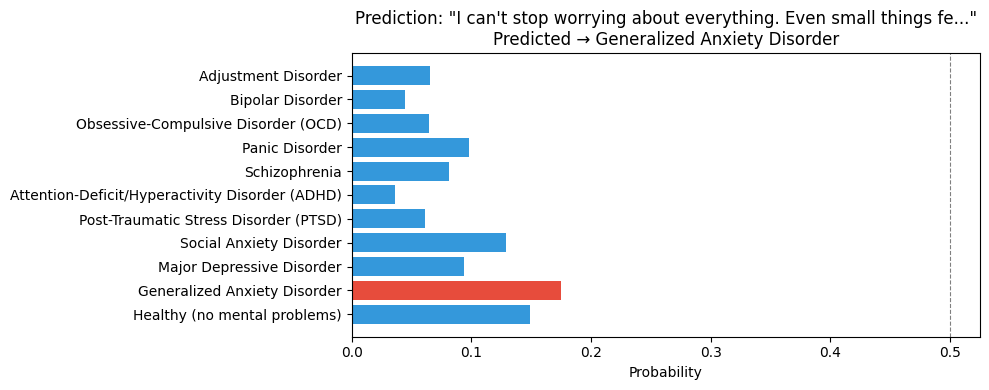

In [13]:
# Visual probability bar chart for a single prediction
text_to_inspect = sample_texts[0]
cls, diag, conf, probs = predict(text_to_inspect)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#e74c3c' if i == cls else '#3498db' for i in range(NUM_LABELS)]
ax.barh([label_map[i] for i in range(NUM_LABELS)], probs, color=colors)
ax.set_xlabel('Probability')
ax.set_title(f'Prediction: "{text_to_inspect[:60]}..."\nPredicted → {diag}')
ax.axvline(0.5, color='grey', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

## 11. Save Full Model & Tokenizer

In [ ]:
SAVE_DIR = "bert_mental_health_model"

model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

# Save the label map for downstream use
import json
with open(f"{SAVE_DIR}/label_map.json", "w") as f:
    json.dump({str(k): v for k, v in label_map.items()}, f, indent=2)

print(f"Model, tokenizer, and label map saved to './{SAVE_DIR}/'")

## 12. Load & Use Saved Model (standalone example)

In [ ]:
from transformers import BertForSequenceClassification, BertTokenizer
import json, torch

SAVE_DIR = "bert_mental_health_model"

loaded_tokenizer = BertTokenizer.from_pretrained(SAVE_DIR)
loaded_model     = BertForSequenceClassification.from_pretrained(SAVE_DIR)
loaded_model     = loaded_model.to(DEVICE)

with open(f"{SAVE_DIR}/label_map.json") as f:
    loaded_label_map = {int(k): v for k, v in json.load(f).items()}

# Test
test_text = "I feel paralysed by sadness. Nothing excites me anymore and I sleep 14 hours a day."
cls, diag, conf, _ = predict(
    test_text,
    model=loaded_model,
    tokenizer=loaded_tokenizer,
    label_map=loaded_label_map
)
print(f"Text      : {test_text}")
print(f"Diagnosis : [{cls}] {diag}  ({conf:.1%} confidence)")